# Bias Analysis: UCI Adult Census Income Dataset
**DATA6550 — Group Project 2: Data Bias**  
**Name:** Jay Beladiya  
**Dataset:** UCI Adult (Census Income), 1994 U.S. Census  

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [2]:
COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train = pd.read_csv('data/adult.data', names=COLUMNS, na_values=['?', ' ?'], skipinitialspace=True)
test  = pd.read_csv('data/adult.test', names=COLUMNS, na_values=['?', ' ?'], skipinitialspace=True, skiprows=1)

train['income'] = train['income'].str.strip()
test['income']  = test['income'].str.strip().str.rstrip('.')

df = pd.concat([train, test], ignore_index=True)
df['income_binary'] = (df['income'] == '>50K').astype(int)

print(f'Full dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Full dataset: 48,842 rows x 16 columns


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


## 2. Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  47985 non-null  object
 14  income          48842 non-null  object
 15  income_binary   48842 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 6.0+ MB


In [4]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_binary
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


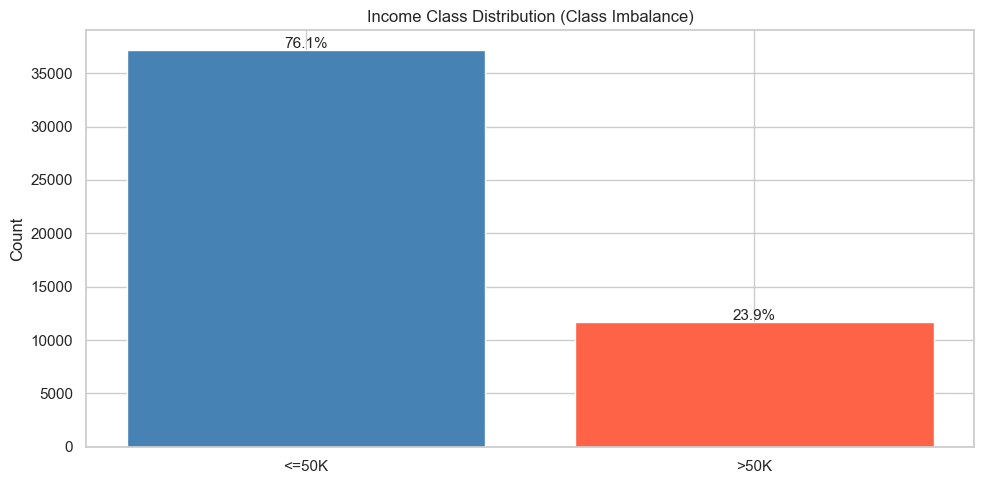

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Class imbalance ratio: 3.18 :1


In [5]:
income_counts = df['income'].value_counts()
income_pct    = df['income'].value_counts(normalize=True) * 100

fig, ax = plt.subplots()
bars = ax.bar(income_counts.index, income_counts.values, color=['steelblue', 'tomato'])
for bar, pct in zip(bars, income_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{pct:.1f}%', ha='center', fontsize=11)
ax.set_title('Income Class Distribution (Class Imbalance)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(income_counts)
print('\nClass imbalance ratio:', round(income_counts.iloc[0] / income_counts.iloc[1], 2), ':1')

## 3. Missing Data Bias

Missing values (?) are not randomly distributed — they cluster in `workclass`, `occupation`, and `native_country` for certain demographic groups. So dropping these rows disproportionately removes specific populations, introducing sampling bias.

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Missing values per column:')
print(missing)
print(f'\nRows with at least one missing value: {df.isnull().any(axis=1).sum():,} ({df.isnull().any(axis=1).mean()*100:.1f}%)')

Missing values per column:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Rows with at least one missing value: 3,620 (7.4%)


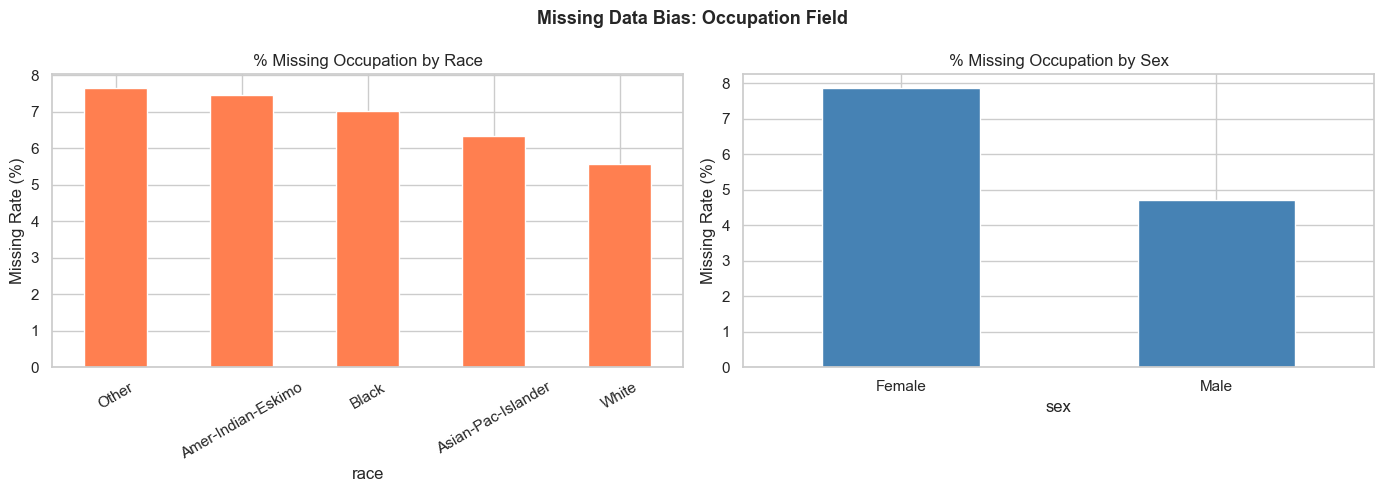

Missing occupation rate by race (%):
race
Amer-Indian-Eskimo    7.45
Asian-Pac-Islander    6.32
Black                 7.02
Other                 7.64
White                 5.55
Name: occupation_missing, dtype: float64

Missing occupation rate by sex (%):
sex
Female    7.86
Male      4.70
Name: occupation_missing, dtype: float64


In [7]:
df['occupation_missing'] = df['occupation'].isnull().astype(int)

miss_by_race = df.groupby('race')['occupation_missing'].mean() * 100
miss_by_sex  = df.groupby('sex')['occupation_missing'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

miss_by_race.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('% Missing Occupation by Race')
axes[0].set_ylabel('Missing Rate (%)')
axes[0].tick_params(axis='x', rotation=30)

miss_by_sex.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('% Missing Occupation by Sex')
axes[1].set_ylabel('Missing Rate (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Missing Data Bias: Occupation Field', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Missing occupation rate by race (%):')
print(miss_by_race.round(2))
print('\nMissing occupation rate by sex (%):')
print(miss_by_sex.round(2))

In [8]:
df['has_missing'] = df[['workclass', 'occupation', 'native_country']].isnull().any(axis=1)
missing_income_rate = df.groupby('has_missing')['income_binary'].mean() * 100
missing_income_rate = missing_income_rate.rename({False: 'Complete rows', True: 'Rows with missing values'})
print('Income >50K rate by missingness status:')
print(missing_income_rate.round(2))

Income >50K rate by missingness status:
has_missing
Complete rows               24.78
Rows with missing values    13.23
Name: income_binary, dtype: float64


## 4. Gender Bias

Women are dramatically underrepresented in the >\$50K class. Sex predicts income nearly as well as legitimate features.  

**Disparate Impact Ratio (DIR):** female_rate / male_rate — values below 0.8 violate the legal four-fifths rule.

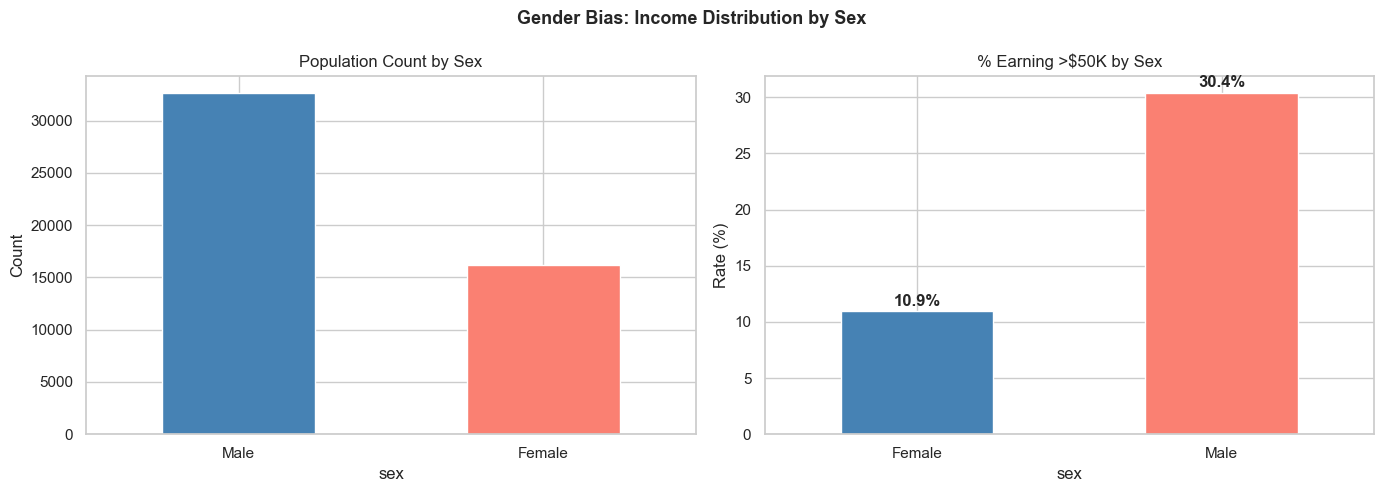

Income >50K rate by sex (%):
sex
Female    10.93
Male      30.38
Name: income_binary, dtype: float64


In [9]:
gender_rate   = df.groupby('sex')['income_binary'].mean() * 100
gender_counts = df['sex'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gender_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Population Count by Sex')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

gender_rate.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('% Earning >$50K by Sex')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(gender_rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Gender Bias: Income Distribution by Sex', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Income >50K rate by sex (%):')
print(gender_rate.round(2))

In [10]:
male_rate   = df[df['sex'] == 'Male']['income_binary'].mean()
female_rate = df[df['sex'] == 'Female']['income_binary'].mean()
gender_dir  = female_rate / male_rate

print('=== Gender Bias Fairness Metrics ===')
print(f'Male   income >50K rate : {male_rate*100:.2f}%')
print(f'Female income >50K rate : {female_rate*100:.2f}%')
print(f'Raw gap (Male - Female)  : {(male_rate - female_rate)*100:.2f} percentage points')
print(f'Disparate Impact Ratio   : {gender_dir:.4f}')
print(f'=> Females earn >50K at {gender_dir:.1%} the rate of males')
if gender_dir < 0.8:
    print('=> DIR < 0.80: Fails the four-fifths rule — legally significant disparate impact')

=== Gender Bias Fairness Metrics ===
Male   income >50K rate : 30.38%
Female income >50K rate : 10.93%
Raw gap (Male - Female)  : 19.45 percentage points
Disparate Impact Ratio   : 0.3597
=> Females earn >50K at 36.0% the rate of males
=> DIR < 0.80: Fails the four-fifths rule — legally significant disparate impact


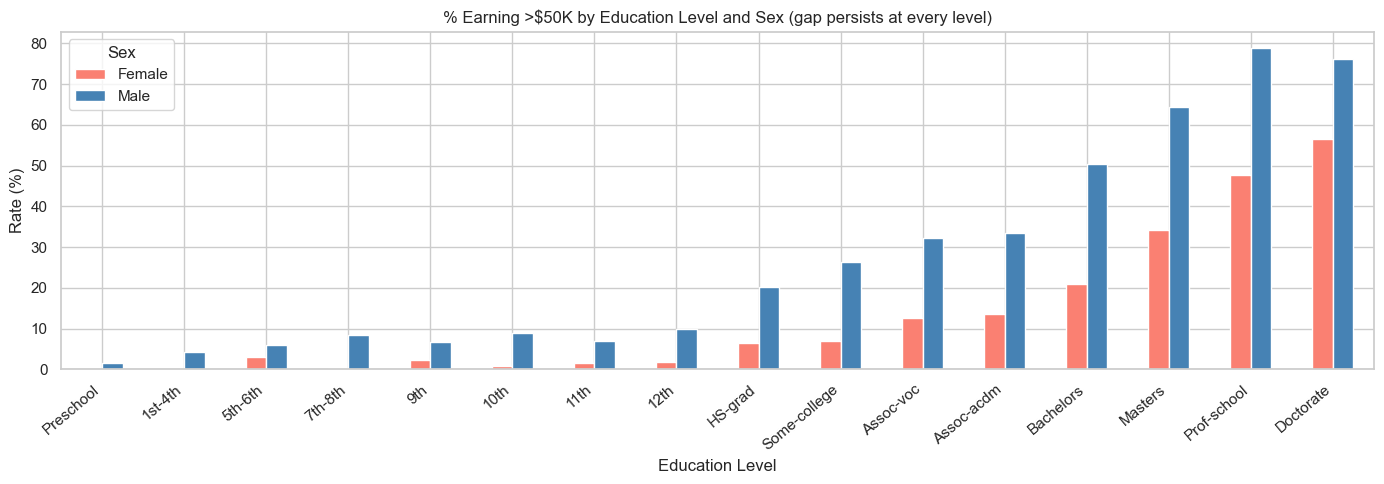

In [11]:
edu_order = ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
             'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
             'Bachelors', 'Masters', 'Prof-school', 'Doctorate']

edu_gender = df.groupby(['education', 'sex'])['income_binary'].mean().unstack() * 100
edu_gender = edu_gender.reindex([e for e in edu_order if e in edu_gender.index])

edu_gender.plot(kind='bar', figsize=(14, 5), color=['salmon', 'steelblue'])
plt.title('% Earning >$50K by Education Level and Sex (gap persists at every level)', fontsize=12)
plt.ylabel('Rate (%)')
plt.xlabel('Education Level')
plt.xticks(rotation=40, ha='right')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

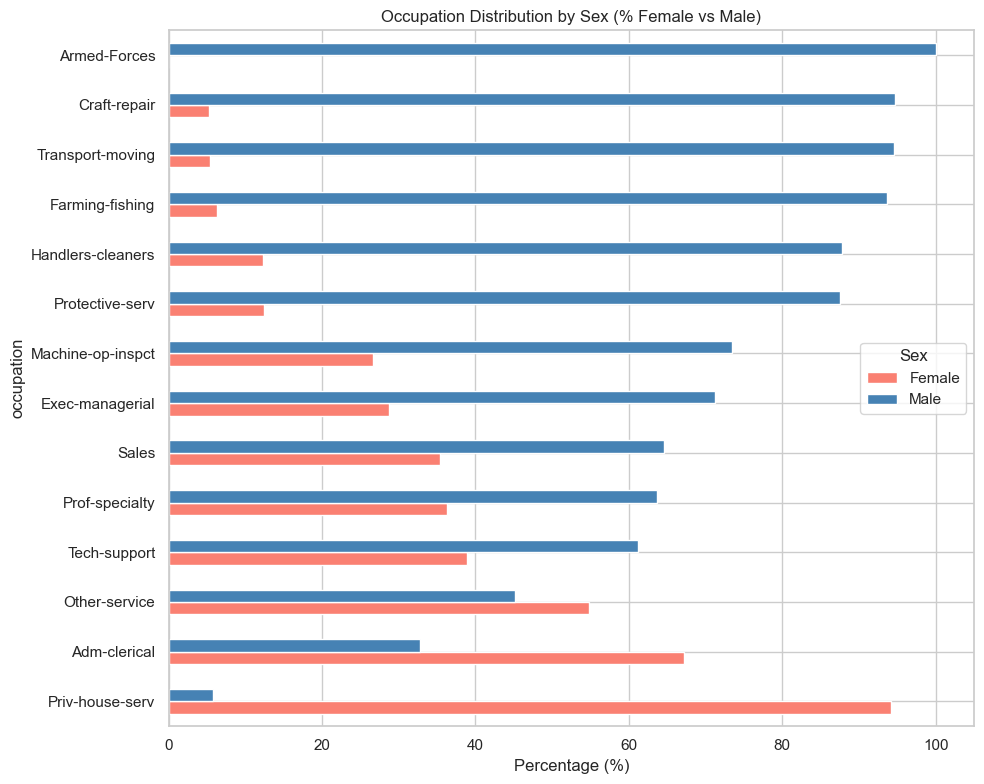

In [12]:
occ_sex = df.dropna(subset=['occupation']).groupby(['occupation', 'sex']).size().unstack(fill_value=0)
occ_sex_pct = occ_sex.div(occ_sex.sum(axis=1), axis=0) * 100
occ_sex_pct = occ_sex_pct.sort_values('Female', ascending=False)

occ_sex_pct[['Female', 'Male']].plot(kind='barh', figsize=(10, 8), color=['salmon', 'steelblue'])
plt.title('Occupation Distribution by Sex (% Female vs Male)', fontsize=12)
plt.xlabel('Percentage (%)')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

## 5. Racial Bias

White respondents are overrepresented in the high-income class relative to Black, Asian-Pacific-Islander, and American-Indian-Eskimo categories, even controlling for education.

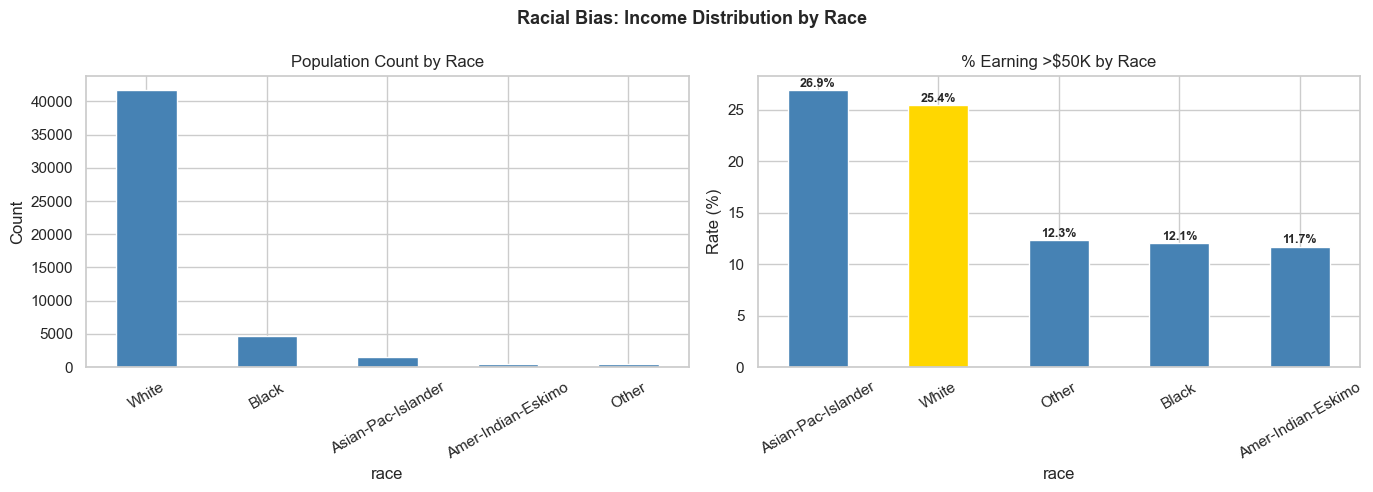

Income >50K rate by race (%):
race
Asian-Pac-Islander    26.93
White                 25.40
Other                 12.32
Black                 12.08
Amer-Indian-Eskimo    11.70
Name: income_binary, dtype: float64


In [13]:
race_rate   = df.groupby('race')['income_binary'].mean().sort_values(ascending=False) * 100
race_counts = df['race'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

race_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Population Count by Race')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

colors = ['gold' if r == 'White' else 'steelblue' for r in race_rate.index]
race_rate.plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('% Earning >$50K by Race')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(race_rate):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Racial Bias: Income Distribution by Race', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Income >50K rate by race (%):')
print(race_rate.round(2))

In [14]:
white_rate = df[df['race'] == 'White']['income_binary'].mean()

print('=== Racial Bias Fairness Metrics (relative to White) ===')
print(f'{"Race":<35} {"Rate":>8} {"DIR":>8} {"Passes 4/5 Rule":>16}')
print('-' * 70)
for race in race_rate.index:
    rate  = df[df['race'] == race]['income_binary'].mean()
    dir_  = rate / white_rate
    passes = 'YES' if (race == 'White' or dir_ >= 0.8) else 'NO  <--'
    print(f'{race:<35} {rate*100:>7.2f}% {dir_:>8.4f} {passes:>16}')

=== Racial Bias Fairness Metrics (relative to White) ===
Race                                    Rate      DIR  Passes 4/5 Rule
----------------------------------------------------------------------
Asian-Pac-Islander                    26.93%   1.0601              YES
White                                 25.40%   1.0000              YES
Other                                 12.32%   0.4849          NO  <--
Black                                 12.08%   0.4757          NO  <--
Amer-Indian-Eskimo                    11.70%   0.4607          NO  <--


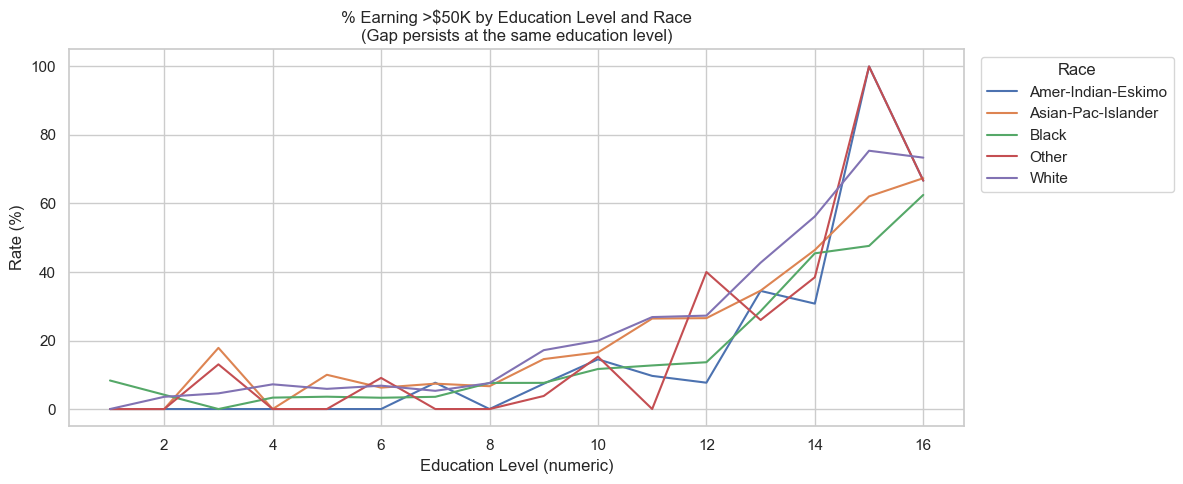

In [15]:
main_races = ['White', 'Black', 'Asian-Pac-Islander', 'Amer-Indian-Eskimo', 'Other']
race_edu = df[df['race'].isin(main_races)].groupby(['education_num', 'race'])['income_binary'].mean().unstack() * 100

race_edu.plot(figsize=(12, 5))
plt.title('% Earning >$50K by Education Level and Race\n(Gap persists at the same education level)', fontsize=12)
plt.xlabel('Education Level (numeric)')
plt.ylabel('Rate (%)')
plt.legend(title='Race', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 6. Age Bias

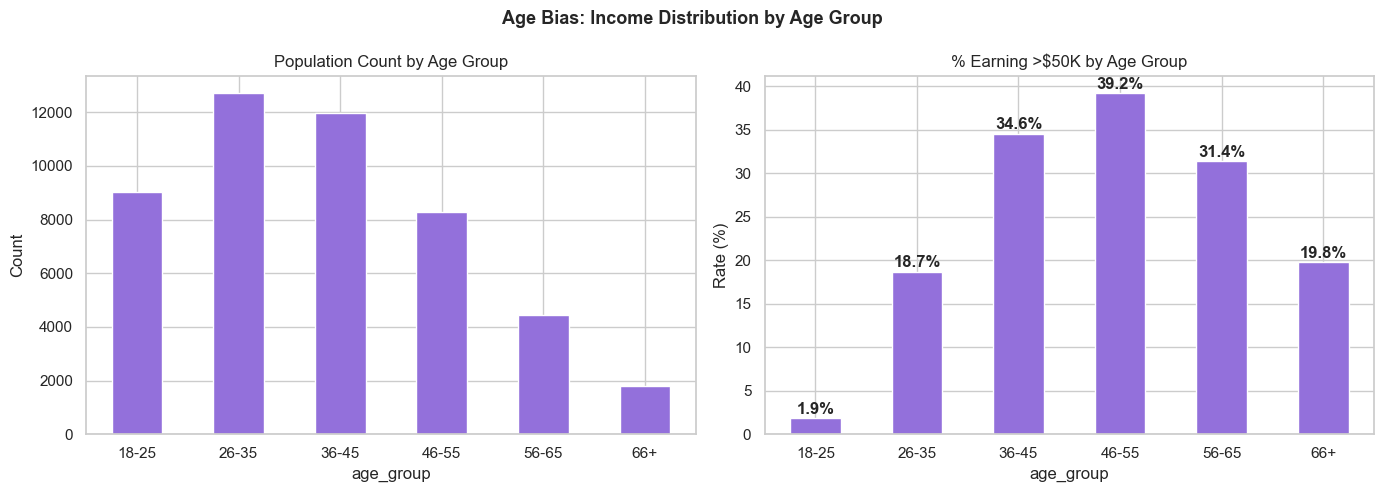

In [16]:
bins   = [17, 25, 35, 45, 55, 65, 100]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

age_rate   = df.groupby('age_group', observed=True)['income_binary'].mean() * 100
age_counts = df['age_group'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Population Count by Age Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

age_rate.plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('% Earning >$50K by Age Group')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(age_rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Age Bias: Income Distribution by Age Group', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

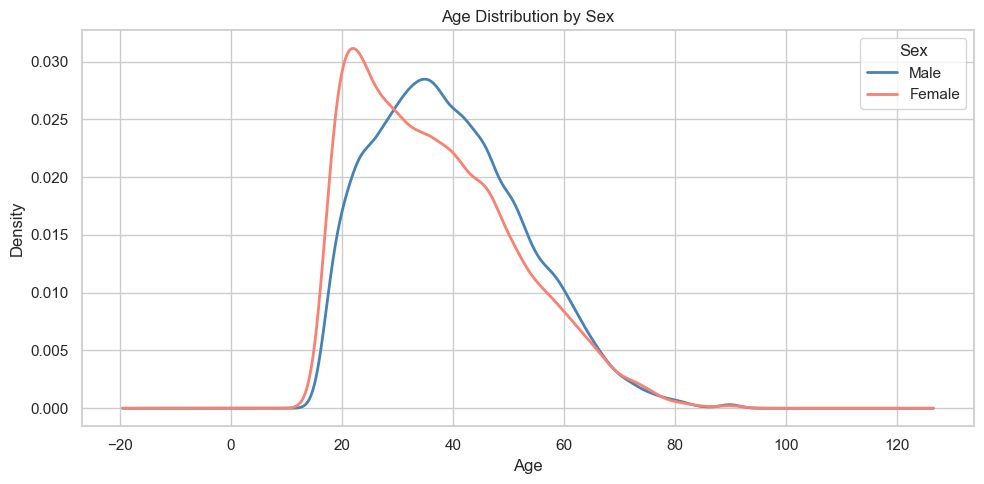

Mean age by sex:
sex
Female    36.93
Male      39.49
Name: age, dtype: float64


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for sex, color in [('Male', 'steelblue'), ('Female', 'salmon')]:
    df[df['sex'] == sex]['age'].plot(kind='kde', ax=ax, label=sex, color=color, linewidth=2)
ax.set_title('Age Distribution by Sex')
ax.set_xlabel('Age')
ax.legend(title='Sex')
plt.tight_layout()
plt.show()

print('Mean age by sex:')
print(df.groupby('sex')['age'].mean().round(2))

## 7. Historical / Temporal Bias

The dataset was collected in **1994** — over 30 years ago. Key implications:
- The \$50K threshold ≈ \$105K in 2024 dollars
- Significant changes in women’s workforce participation since 1994
- Occupations are based on the pre-internet economy (not relevant occupations)
- Any model trained on this data will have outdated societal structures as current facts

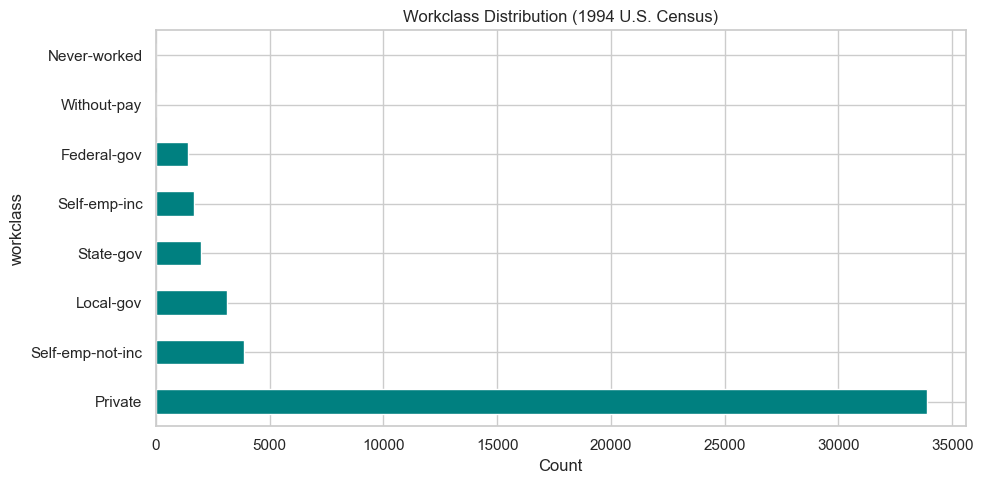

Top 15 occupations:
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64


In [18]:
wc = df['workclass'].value_counts(dropna=True)
wc.plot(kind='barh', color='teal', figsize=(10, 5))
plt.title('Workclass Distribution (1994 U.S. Census)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

print('Top 15 occupations:')
print(df['occupation'].value_counts(dropna=True).head(15))

---
## 8. Summary of Biases Found

| Bias Type | Finding | Metric |
|-----------|---------|--------|
| **Gender** | Women earn >\$50K at ~11% vs men's ~30% | DIR ≈ 0.36 — fails four-fifths rule |
| **Race** | Black earners have lowest high-income rate; White highest | DIR for Black vs White < 0.8 |
| **Missing data** | Missing occupation/workclass clusters in certain race groups | Non-random (not MCAR) |
| **Age** | Peak income in 36–55 range; young and elderly underrepresented | Life-cycle + structural |
| **Historical** | 1994 data encodes outdated occupational and social structures | \$50K ≈ \$105K in 2024 dollars |


---
## 9. Bias Mitigation Strategies

### Pre-processing
- Weight instances so privileged/unprivileged groups balance in training
- **Disparate Impact Remover:** Repair feature distributions to remove correlations with sensitive attributes

### In-processing
- **Adversarial Debiasing:** Train a second model to predict sensitive attributes from outputs; penalize the main model for leaking them
- **Fairness constraints:** Add demographic parity or equalized odds directly to the loss function

### Post-processing
- **Equalized Odds Post-processing:** Adjust per-group prediction thresholds to equalize TPR/FPR

### Tools
- **IBM AI Fairness 360 (`aif360`):** All three categories, Adult Census built-in demos
- **Microsoft Fairlearn:** Fairness dashboard + reduction-based mitigations